In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# K-Nearest Neighbors (KNN) Example: Iris Flower Classification

This comprehensive notebook demonstrates the complete KNN workflow including:
- Exploratory Data Analysis (EDA)
- Train-Test Split with Feature Scaling
- Algorithm Selection and Model Fitting
- Predictions and Evaluation
- Metrics: Accuracy, Precision, F1 Score, Recall
- Visualizations and Plots
- Finding Optimal K Value
- Testing with External/New Data

In [2]:
# Step 1: Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['flower_name'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("Dataset Overview:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nTarget classes: {df['flower_name'].unique()}")

Dataset Overview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target flower_name  
0       0      Setosa  
1       0      Setosa  
2       0      Setosa  
3       0      Setosa  
4       0      Setosa  

Dataset shape: (150, 6)

Target classes: ['Setosa' 'Versicolor' 'Virginica']


Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Missing values:
sepal length (cm)    0
sepal width

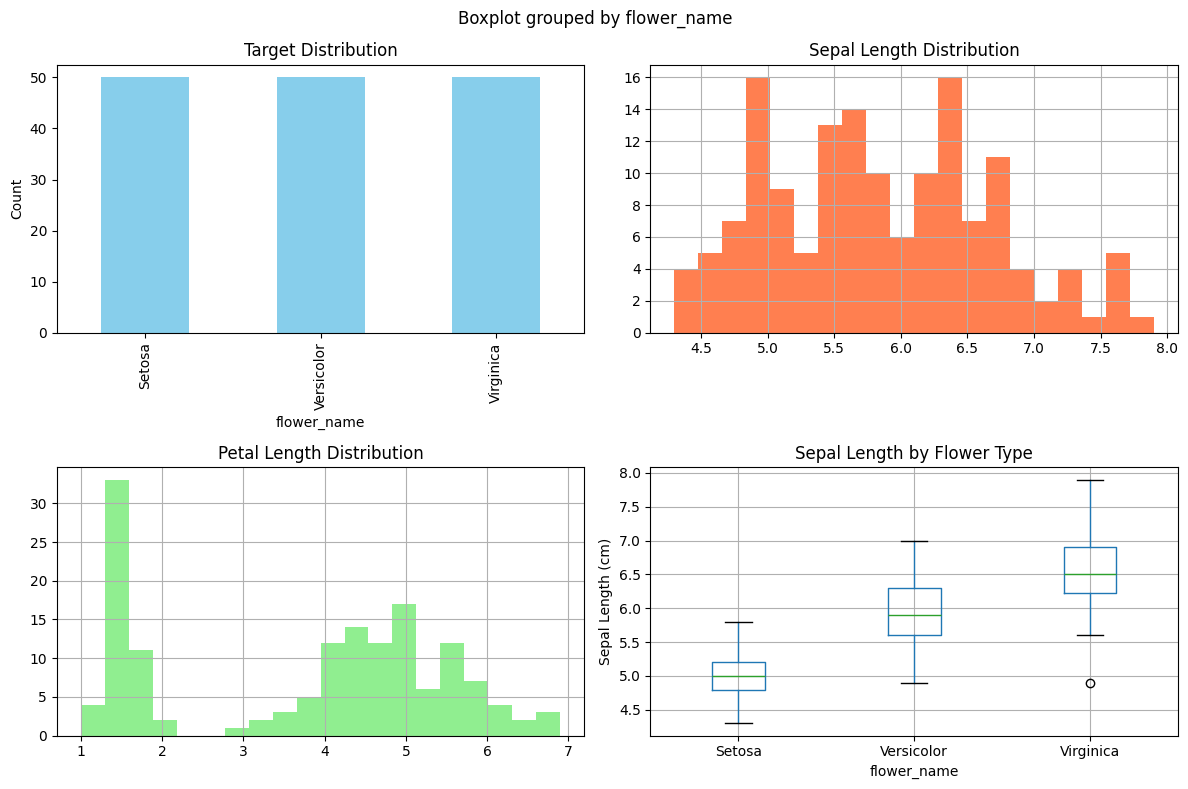

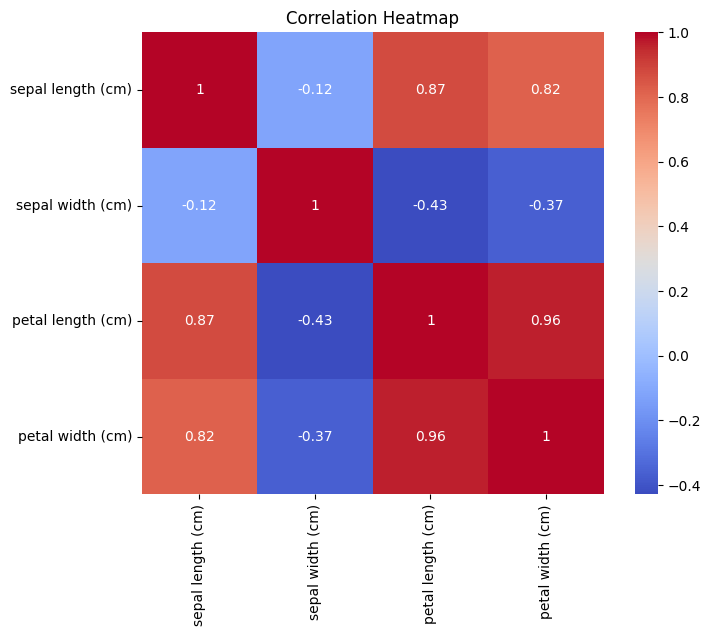

In [16]:
# Step 2: Exploratory Data Analysis (EDA)

# Basic statistics
print("Statistical Summary:")
print(df.describe())

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Target distribution
print("\nTarget distribution:")
print(df['flower_name'].value_counts())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Target distribution
df['flower_name'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Target Distribution')
axes[0, 0].set_ylabel('Count')

# Feature distributions
df['sepal length (cm)'].hist(ax=axes[0, 1], bins=20, color='coral')
axes[0, 1].set_title('Sepal Length Distribution')

df['petal length (cm)'].hist(ax=axes[1, 0], bins=20, color='lightgreen')
axes[1, 0].set_title('Petal Length Distribution')

# Box plot by target
df.boxplot(column='sepal length (cm)', by='flower_name', ax=axes[1, 1])
axes[1, 1].set_title('Sepal Length by Flower Type')
axes[1, 1].set_ylabel('Sepal Length (cm)')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df.iloc[:, :4].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

In [17]:
# Step 3: Train-Test Split and Feature Scaling

# Prepare features and target
X = df.iloc[:, :4]  # Features: all columns except target
y = df['target']     # Target

# Split the data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining target distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nTesting target distribution:\n{pd.Series(y_test).value_counts()}")

# Feature Scaling (Important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling completed!")
print(f"Mean of scaled training features: {X_train_scaled.mean(axis=0)}")
print(f"Std of scaled training features: {X_train_scaled.std(axis=0)}")

Training set size: (120, 4)
Testing set size: (30, 4)

Training target distribution:
target
0    40
2    40
1    40
Name: count, dtype: int64

Testing target distribution:
target
0    10
2    10
1    10
Name: count, dtype: int64

Feature scaling completed!
Mean of scaled training features: [-1.20829273e-15 -2.03679666e-15  4.99600361e-16  1.67458640e-15]
Std of scaled training features: [1. 1. 1. 1.]


In [18]:
# Step 4: Choose Algorithm and Fit the Model

# Create KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the model
knn.fit(X_train_scaled, y_train)

print("KNN Model Parameters:")
print(f"Number of neighbors (k): {knn.n_neighbors}")
print(f"Algorithm: {knn.algorithm}")
print(f"Distance metric: {knn.metric}")
print(f"\nModel trained successfully!")

KNN Model Parameters:
Number of neighbors (k): 5
Algorithm: auto
Distance metric: minkowski

Model trained successfully!


In [19]:
# Step 5: Make Predictions

# Predictions on test set
y_pred = knn.predict(X_test_scaled)

# Prediction probabilities
y_pred_proba = knn.predict_proba(X_test_scaled)

print("First 10 predictions:")
print(y_pred[:10])
print("\nFirst 10 actual values:")
print(y_test.values[:10])
print("\nFirst 10 prediction probabilities (for each class):")
print(y_pred_proba[:10])

First 10 predictions:
[0 2 1 1 0 1 0 0 2 1]

First 10 actual values:
[0 2 1 1 0 1 0 0 2 1]

First 10 prediction probabilities (for each class):
[[1.  0.  0. ]
 [0.  0.4 0.6]
 [0.  1.  0. ]
 [0.  1.  0. ]
 [1.  0.  0. ]
 [0.  0.6 0.4]
 [1.  0.  0. ]
 [1.  0.  0. ]
 [0.  0.  1. ]
 [0.  1.  0. ]]


In [20]:
# Step 6: Model Evaluation and Metrics

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Per-class metrics
print("\nPer-class Metrics:")
print(classification_report(y_test, y_pred, target_names=['Setosa', 'Versicolor', 'Virginica']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.9333
Precision: 0.9444
Recall: 0.9333
F1 Score: 0.9327

Per-class Metrics:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.83      1.00      0.91        10
   Virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


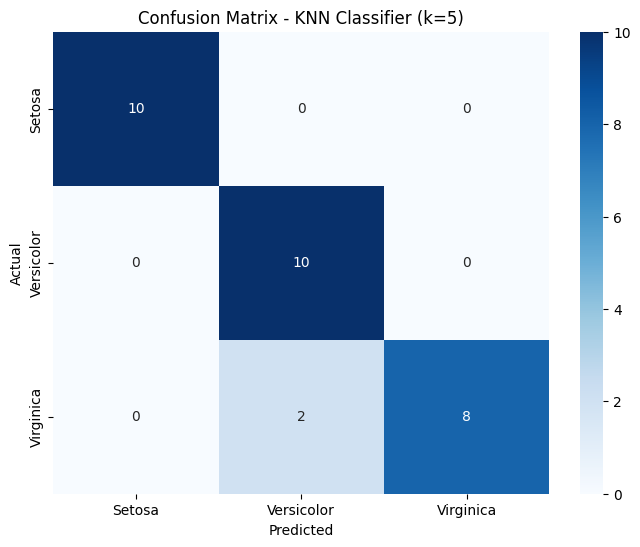

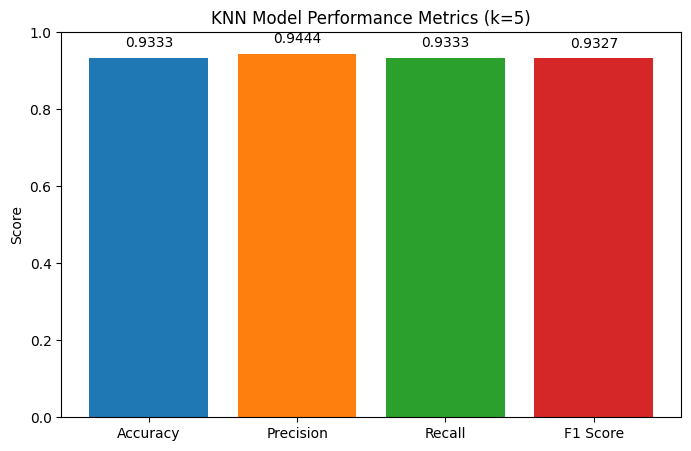

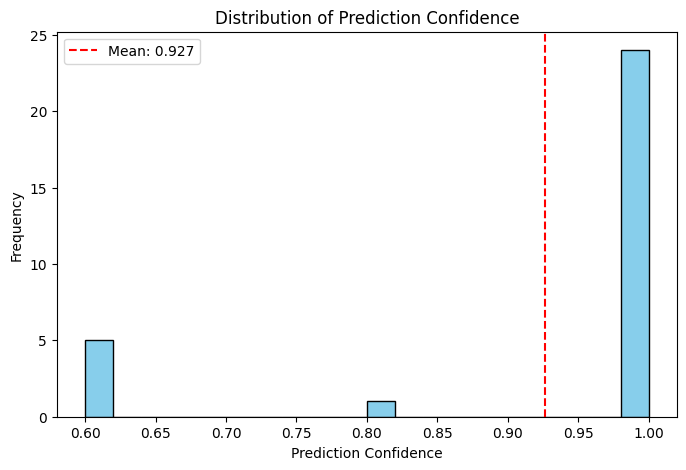

In [21]:
# Step 7: Visualization and Plotting

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Confusion Matrix - KNN Classifier (k=5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylim([0, 1])
plt.ylabel('Score')
plt.title('KNN Model Performance Metrics (k=5)')
for i, (metric, value) in enumerate(zip(metrics, values)):
    plt.text(i, value + 0.02, f'{value:.4f}', ha='center', va='bottom')
plt.show()

# Prediction confidence distribution
max_prob = np.max(y_pred_proba, axis=1)
plt.figure(figsize=(8, 5))
plt.hist(max_prob, bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Prediction Confidence')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Confidence')
plt.axvline(x=np.mean(max_prob), color='red', linestyle='--', label=f'Mean: {np.mean(max_prob):.3f}')
plt.legend()
plt.show()

Optimal K value: 1 with test accuracy: 0.9667


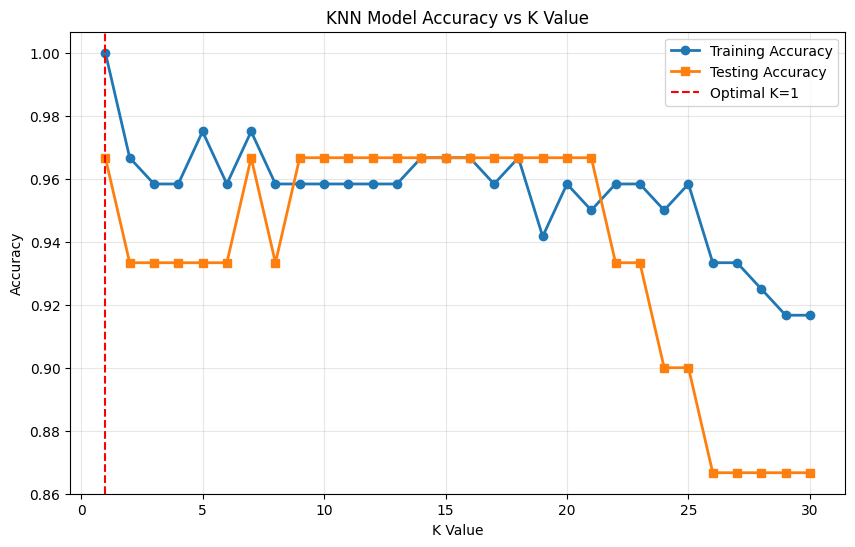

In [22]:
# Step 8: Finding Optimal K Value

# Test different K values
k_values = range(1, 31)
train_scores = []
test_scores = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    
    train_score = knn_k.score(X_train_scaled, y_train)
    test_score = knn_k.score(X_test_scaled, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)

# Find optimal K
optimal_k = k_values[np.argmax(test_scores)]
print(f"Optimal K value: {optimal_k} with test accuracy: {max(test_scores):.4f}")

# Plot K vs Accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, marker='o', label='Training Accuracy', linewidth=2)
plt.plot(k_values, test_scores, marker='s', label='Testing Accuracy', linewidth=2)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Model Accuracy vs K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

External Data Testing (Real-time Predictions):
Sepal L.   Sepal W.   Petal L.   Petal W.   Prediction      Confidence
5.10       3.50       1.40       0.20       Setosa          1.0000    
6.20       2.90       4.30       1.30       Versicolor      1.0000    
7.10       3.00       5.90       2.10       Virginica       1.0000    
4.90       3.00       1.40       0.20       Setosa          1.0000    
6.50       3.00       4.50       1.50       Versicolor      1.0000    
7.60       3.00       6.60       2.20       Virginica       1.0000    


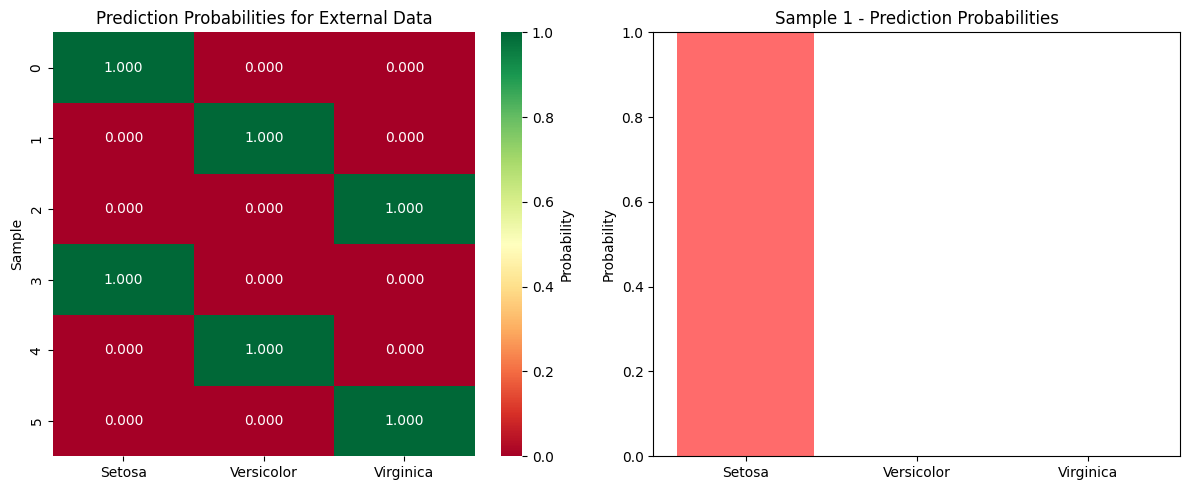

In [23]:
# Step 9: Testing with External/New Data (Real-time Example)

# Create custom external data for testing
# [sepal_length, sepal_width, petal_length, petal_width]
external_data = np.array([
    [5.1, 3.5, 1.4, 0.2],    # Expected: Setosa
    [6.2, 2.9, 4.3, 1.3],    # Expected: Versicolor
    [7.1, 3.0, 5.9, 2.1],    # Expected: Virginica
    [4.9, 3.0, 1.4, 0.2],    # Expected: Setosa
    [6.5, 3.0, 4.5, 1.5],    # Expected: Versicolor
    [7.6, 3.0, 6.6, 2.2]     # Expected: Virginica
])

# Scale the external data using the same scaler
external_data_scaled = scaler.transform(external_data)

# Make predictions
external_predictions = knn.predict(external_data_scaled)
external_proba = knn.predict_proba(external_data_scaled)

# Map predictions to flower names
flower_names = ['Setosa', 'Versicolor', 'Virginica']
predicted_names = [flower_names[p] for p in external_predictions]

# Display results
print("External Data Testing (Real-time Predictions):")
print("=" * 100)
print(f"{'Sepal L.':<10} {'Sepal W.':<10} {'Petal L.':<10} {'Petal W.':<10} {'Prediction':<15} {'Confidence':<10}")
print("=" * 100)

for i, (data, pred, proba) in enumerate(zip(external_data, external_predictions, external_proba)):
    confidence = proba[pred]
    print(f"{data[0]:<10.2f} {data[1]:<10.2f} {data[2]:<10.2f} {data[3]:<10.2f} {flower_names[pred]:<15} {confidence:<10.4f}")

# Visualize prediction probabilities
plt.figure(figsize=(12, 5))

# Prediction probabilities heatmap
plt.subplot(1, 2, 1)
sns.heatmap(external_proba, annot=True, fmt='.3f', cmap='RdYlGn', 
            xticklabels=flower_names, cbar_kws={'label': 'Probability'})
plt.ylabel('Sample')
plt.title('Prediction Probabilities for External Data')

# Bar chart for first sample
plt.subplot(1, 2, 2)
plt.bar(flower_names, external_proba[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.ylabel('Probability')
plt.title('Sample 1 - Prediction Probabilities')
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

Model Comparison with Different K Values on Test Set:
K Value    Accuracy     Precision    Recall       F1 Score    
3          0.9333       0.9444       0.9333       0.9327      
5          0.9333       0.9444       0.9333       0.9327      
7          0.9667       0.9697       0.9667       0.9666      
9          0.9667       0.9697       0.9667       0.9666      


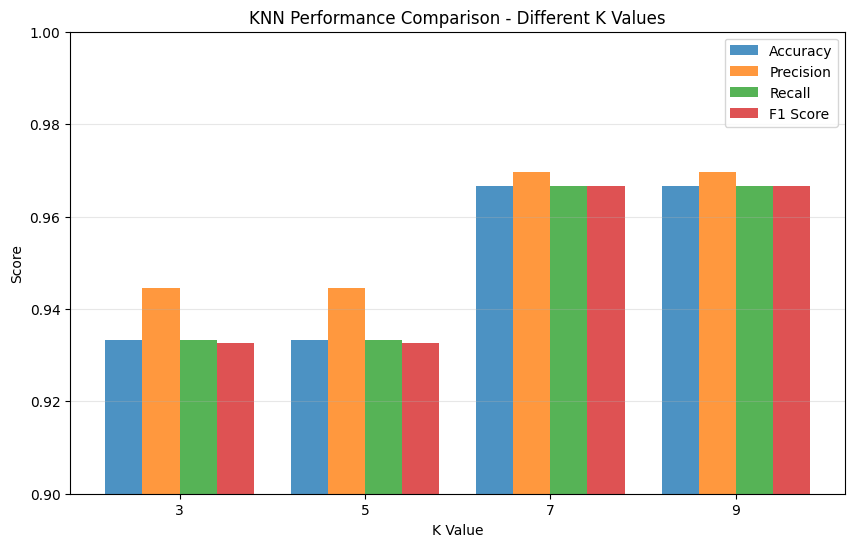


Summary: KNN effectively handles classification by finding similar patterns in data.
Feature scaling is crucial for distance-based algorithms like KNN.
For this dataset, K=1 provides the best balance between bias and variance.


In [24]:
# Step 10: Model Comparison with Different K Values

# Train models with different K values
k_comparison = [3, 5, 7, 9]
comparison_results = []

print("Model Comparison with Different K Values on Test Set:")
print("=" * 80)
print(f"{'K Value':<10} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("=" * 80)

for k in k_comparison:
    knn_compare = KNeighborsClassifier(n_neighbors=k)
    knn_compare.fit(X_train_scaled, y_train)
    
    y_pred_compare = knn_compare.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred_compare)
    prec = precision_score(y_test, y_pred_compare, average='weighted')
    rec = recall_score(y_test, y_pred_compare, average='weighted')
    f1_compare = f1_score(y_test, y_pred_compare, average='weighted')
    
    comparison_results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1_compare
    })
    
    print(f"{k:<10} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1_compare:<12.4f}")

# Visualize comparison
comparison_df = pd.DataFrame(comparison_results)

plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.2

plt.bar(x - width*1.5, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
plt.bar(x - width*0.5, comparison_df['Precision'], width, label='Precision', alpha=0.8)
plt.bar(x + width*0.5, comparison_df['Recall'], width, label='Recall', alpha=0.8)
plt.bar(x + width*1.5, comparison_df['F1'], width, label='F1 Score', alpha=0.8)

plt.xlabel('K Value')
plt.ylabel('Score')
plt.title('KNN Performance Comparison - Different K Values')
plt.xticks(x, comparison_df['K'])
plt.legend()
plt.ylim([0.9, 1.0])
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print("\n" + "=" * 80)
print("Summary: KNN effectively handles classification by finding similar patterns in data.")
print("Feature scaling is crucial for distance-based algorithms like KNN.")
print(f"For this dataset, K={optimal_k} provides the best balance between bias and variance.")